In [8]:
import pandas as pd

# Etapa 1: Separar apenas atributos relevantes
Primeiramente precisamos isolar 1-3 colunas de identificação dos jogadores e os seus respectivos atributos de outras informações irrelevantes como peso e altura.

In [9]:
players_data = pd.read_csv("players_22.csv")
print("Initial shape of players_data:", players_data.shape)

columns_to_remove = [
    "sofifa_id", "player_url", "age", "dob", "height_cm", "weight_kg",
    "club_team_id", "league_name", "club_position", "club_jersey_number",
    "club_loaned_from", "club_joined", "club_contract_valid_until",
    "nationality_id", "nation_team_id", "nation_position", "nation_jersey_number",
    "skill_moves", "international_reputation", "work_rate", "body_type", "real_face",
    "release_clause_eur", "player_face_url", "club_logo_url", "club_flag_url",
    "nation_logo_url", "nation_flag_url"
]

players_data = players_data.drop(columns=columns_to_remove)

print("Colunas removidas por pouca relevância:")
for column in columns_to_remove:
    print(column)

Initial shape of players_data: (19239, 110)
Colunas removidas por pouca relevância:
sofifa_id
player_url
age
dob
height_cm
weight_kg
club_team_id
league_name
club_position
club_jersey_number
club_loaned_from
club_joined
club_contract_valid_until
nationality_id
nation_team_id
nation_position
nation_jersey_number
skill_moves
international_reputation
work_rate
body_type
real_face
release_clause_eur
player_face_url
club_logo_url
club_flag_url
nation_logo_url
nation_flag_url


/tmp/ipykernel_16884/1061143309.py:1: DtypeWarning: Columns (0: nation_position, 1: nation_logo_url) have mixed types. Specify dtype option on import or set low_memory=False.
  players_data = pd.read_csv("players_22.csv")


# Etapa 2: Separar apenas atributos numéricos
Atributos não-numéricos podem ser relevantes no futuro, mas não há como encontrar uma correlação clara.

In [10]:
non_numeric_columns = players_data.select_dtypes(exclude=['number']).columns
other_columns_to_remove = ["overall", "value_eur", "wage_eur", "league_level", "weak_foot"]

player_attributes = players_data.drop(columns=non_numeric_columns)
player_attributes = player_attributes.drop(columns=other_columns_to_remove)


# Etapa 3: Analisar redundâncias

Strong correlations (absolute value >= 0.8):
defending                  defending_standing_tackle    0.977879
defending_standing_tackle  defending_sliding_tackle     0.977414
goalkeeping_diving         goalkeeping_reflexes         0.973929
movement_acceleration      goalkeeping_speed            0.973703
pace                       movement_sprint_speed        0.972264
                                                          ...   
attacking_crossing         mentality_positioning        0.803924
skill_ball_control         goalkeeping_handling        -0.802568
passing                    skill_curve                  0.802441
skill_ball_control         goalkeeping_reflexes        -0.802410
attacking_finishing        skill_ball_control           0.801521
Length: 78, dtype: float64


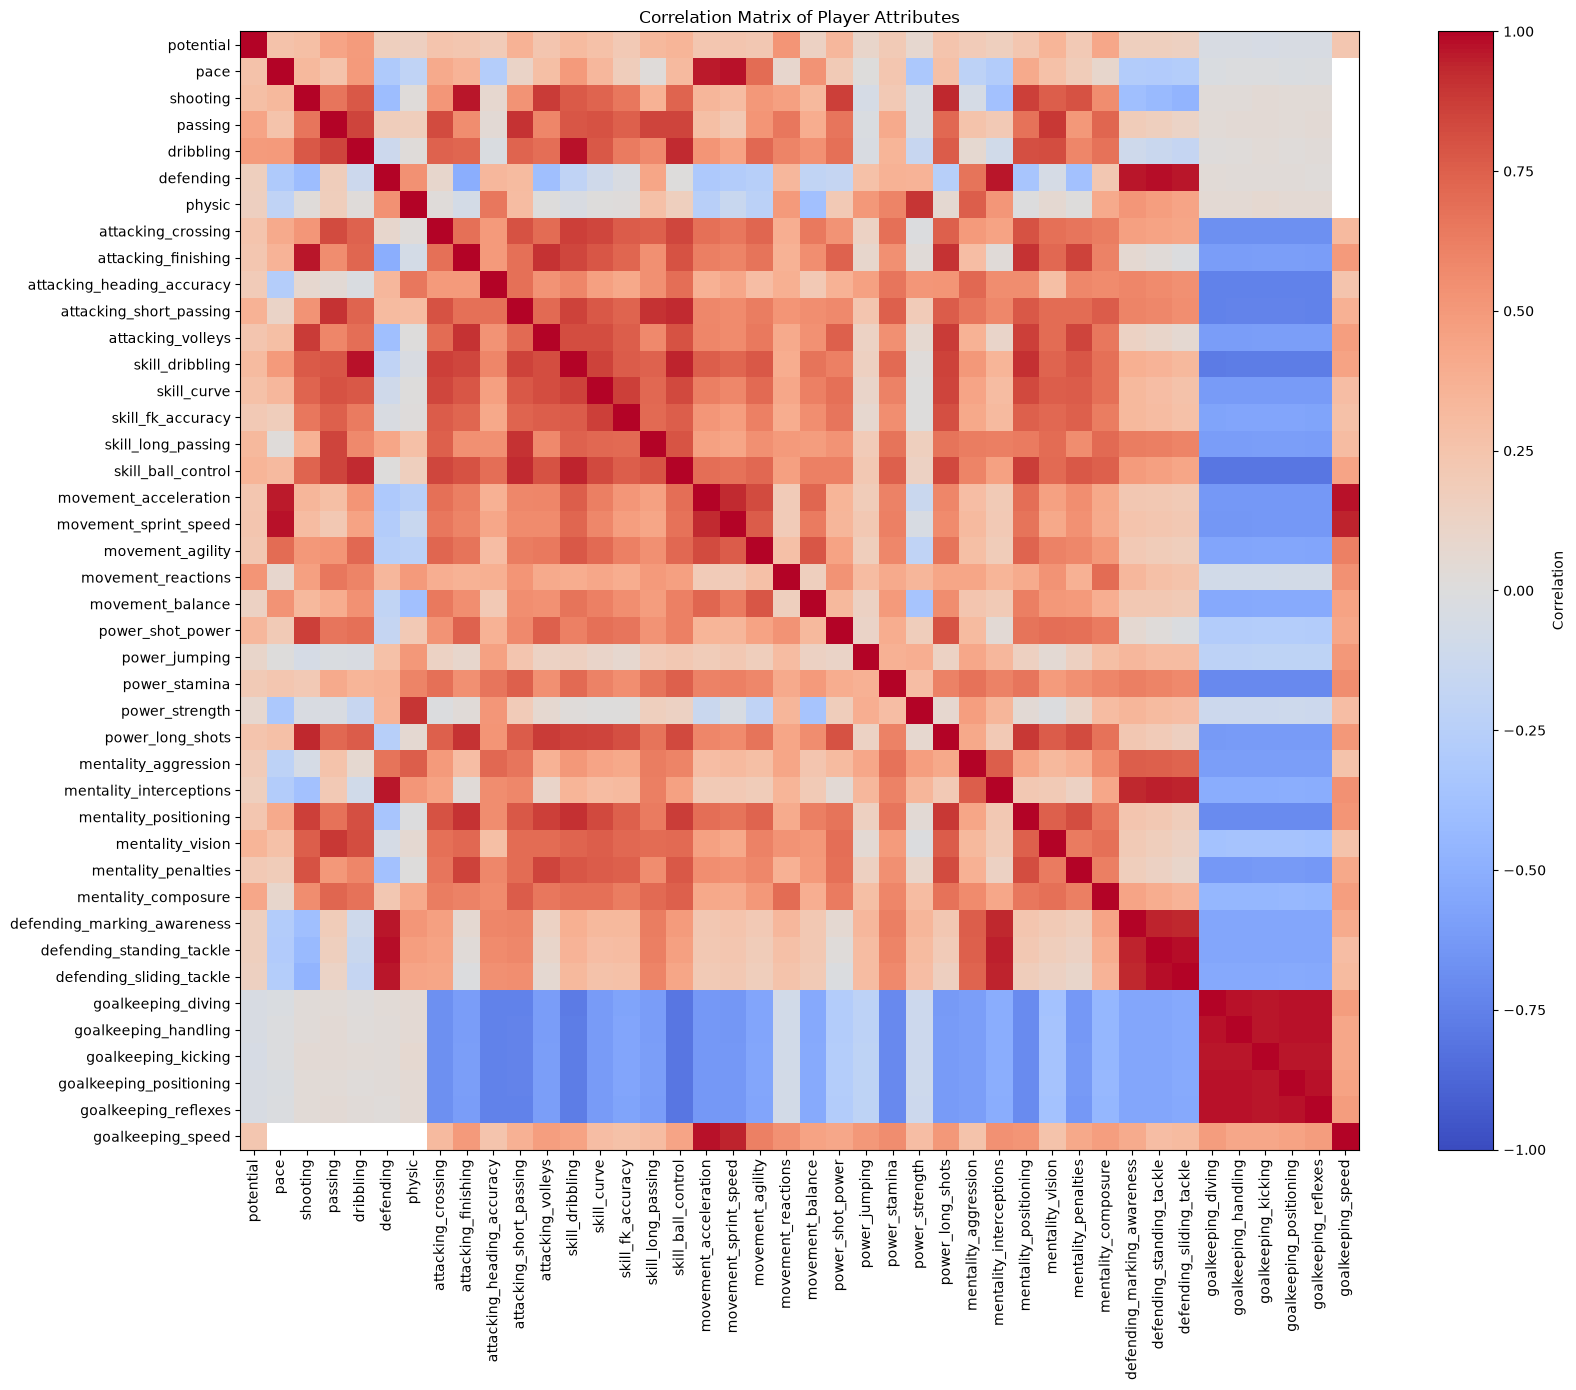

In [11]:
correlation_matrix = player_attributes.corr()

# Show highly correlated pairs without repeating the same pair twice.
correlation_pairs = correlation_matrix.where(
    __import__("numpy").triu(
        __import__("numpy").ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
).stack()
strong_correlations = correlation_pairs[
    correlation_pairs.abs() >= 0.8
].sort_values(key=abs, ascending=False)

print("Strong correlations (absolute value >= 0.8):")
print(strong_correlations)

# Display the complete correlation matrix.
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Player Attributes")
plt.tight_layout()
plt.show()

# Etapa 4: Remover atributos correlatos
Muitos atributos carregam a mesma informação, então aqui iremos escolher os que ficam.

In [12]:
redundant_columns = ['power_strength', 'defending_sliding_tackle', 'goalkeeping_diving', 'mentality_vision', 'attacking_volleys', 'attacking_crossing', 'goalkeeping_handling', 'defending_standing_tackle', 'attacking_finishing', 'goalkeeping_kicking', 'skill_dribbling', 'skill_long_passing', 'mentality_positioning', 'skill_ball_control', 'mentality_interceptions', 'movement_acceleration', 'movement_sprint_speed', 'power_shot_power', 'skill_curve', 'skill_fk_accuracy', 'power_long_shots', 'goalkeeping_speed', 'defending_marking_awareness', 'goalkeeping_positioning', 'attacking_short_passing']
player_attributes = player_attributes.drop(columns=redundant_columns)
players_data = players_data.drop(columns=redundant_columns)

print("Colunas removidas devido a alta correlação:")
for column in redundant_columns:
    print(column)

Colunas removidas devido a alta correlação:
power_strength
defending_sliding_tackle
goalkeeping_diving
mentality_vision
attacking_volleys
attacking_crossing
goalkeeping_handling
defending_standing_tackle
attacking_finishing
goalkeeping_kicking
skill_dribbling
skill_long_passing
mentality_positioning
skill_ball_control
mentality_interceptions
movement_acceleration
movement_sprint_speed
power_shot_power
skill_curve
skill_fk_accuracy
power_long_shots
goalkeeping_speed
defending_marking_awareness
goalkeeping_positioning
attacking_short_passing


In [14]:
print("Final shape of players_data:", players_data.shape)
print("Final shape of player_attributes:", player_attributes.shape)

Final shape of players_data: (19239, 57)
Final shape of player_attributes: (19239, 17)
